In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

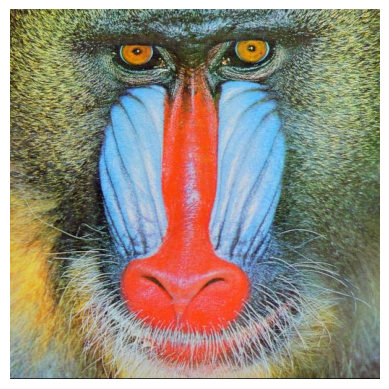

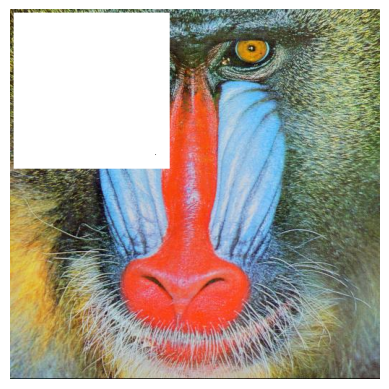

In [16]:
mandril = cv2.imread("mandril.jpg", cv2.IMREAD_COLOR)
mandril = cv2.cvtColor(mandril, cv2.COLOR_BGR2RGB)

lena = cv2.imread("lena.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(mandril)
plt.axis("off")
plt.show()

cv2.imwrite("mandril.png", mandril)

cv2.rectangle(mandril, (5,5), (220,220), (255,255,255), -1)
mandril[201, 201] = (0, 0, 0)

plt.imshow(mandril)
plt.axis("off")
plt.show()

cv2.waitKey(10)
cv2.destroyAllWindows()

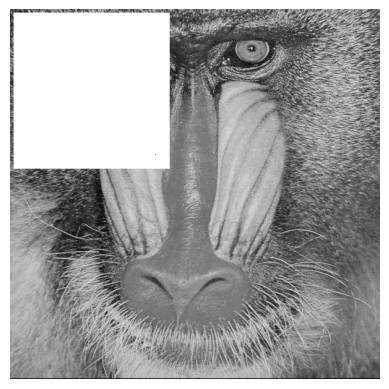

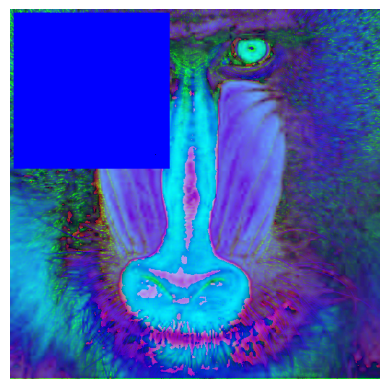

H: 
 [[23 23 22 ... 31 33 33]
 [23 23 21 ... 31 33 33]
 [24 24 22 ... 32 34 34]
 ...
 [84 84 84 ... 13 13 13]
 [79 79 79 ...  8  8  8]
 [76 74 75 ...  8  6  0]]
S: 
 [[105 205 255 ...  67  51  45]
 [131 143 255 ...  63  60  63]
 [205 117 224 ... 117 112 135]
 ...
 [ 27  27  32 ...  25  26  26]
 [ 28  29  32 ...  33  34  35]
 [228 255 255 ... 200 255 255]]
V: 
 [[163  76  54 ... 122 154 174]
 [132 112  49 ... 138 149 142]
 [ 87 142  66 ...  94 100  83]
 ...
 [152 152 150 ...  91  88  88]
 [155 148 137 ...  86  83  81]
 [ 19  15  12 ...  14  10   7]]


In [17]:
mandril_gray = cv2.cvtColor(mandril, cv2.COLOR_RGB2GRAY)
mandril_hsv = cv2.cvtColor(mandril, cv2.COLOR_RGB2HSV)

plt.imshow(mandril_gray, cmap='gray'); plt.axis("off"); plt.show()
plt.imshow(mandril_hsv); plt.axis("off"); plt.show()

mandrilH = mandril_hsv[:,:,0]
mandrilS = mandril_hsv[:,:,1]
mandrilV = mandril_hsv[:,:,2]

print("H: \n", mandrilH)
print("S: \n", mandrilS)
print("V: \n", mandrilV)

cv2.waitKey(10)
cv2.destroyAllWindows()

(900, 900, 3)


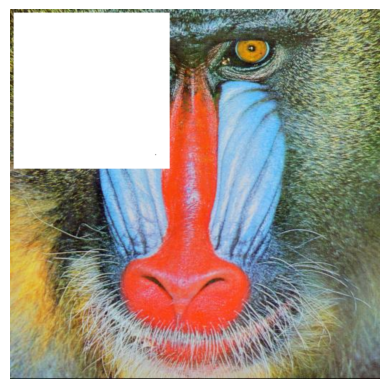

In [18]:
mandril_resized = cv2.resize(mandril, (900,900))
print(mandril_resized.shape)
plt.imshow(mandril_resized); plt.axis('off'); plt.show()

cv2.waitKey(10)
cv2.destroyAllWindows()

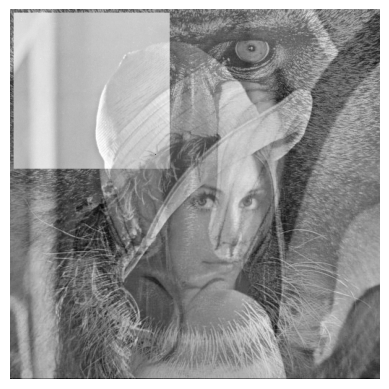

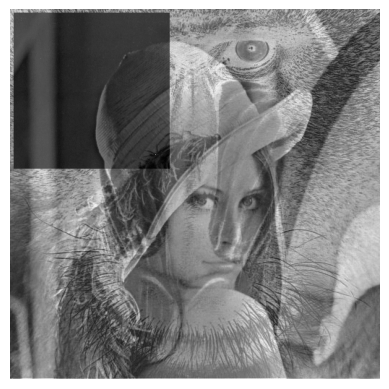

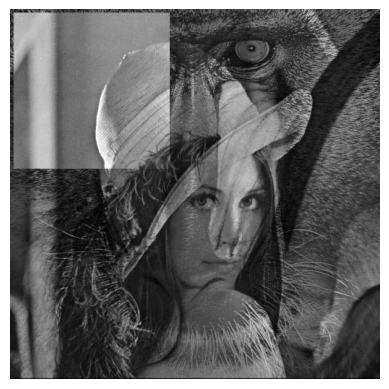

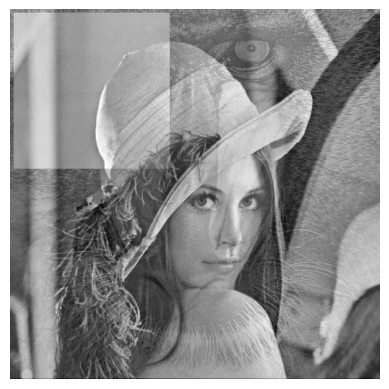

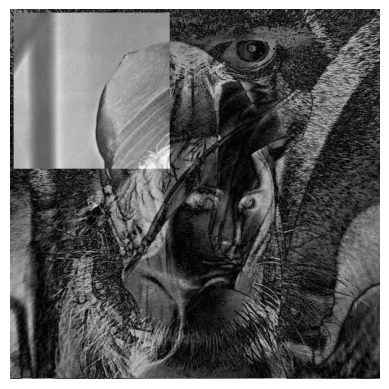

In [19]:
mandril_gray = cv2.cvtColor(mandril, cv2.COLOR_RGB2GRAY).astype('double')
plt.imshow(lena + mandril_gray, cmap='gray'); plt.axis('off'); plt.show()
plt.imshow(lena - mandril_gray, cmap='gray'); plt.axis('off'); plt.show()
plt.imshow(lena * mandril_gray, cmap='gray'); plt.axis('off'); plt.show()
plt.imshow(cv2.addWeighted(lena.astype('double'), 0.7, mandril_gray, 0.3, 0),cmap='gray'); plt.axis('off'); plt.show()
plt.imshow(cv2.absdiff(lena.astype('uint8'), mandril_gray.astype('uint8')), cmap='gray');plt.axis('off'); plt.show()

cv2.waitKey(10)
cv2.destroyAllWindows()

In [20]:
def hist(img):
    h = np.zeros ((256 ,1), np.float32) 
    height, width = img.shape[:2]

    for y in range(height):
        for x in range(width):
            h[img[y,x]] += 1
    return h

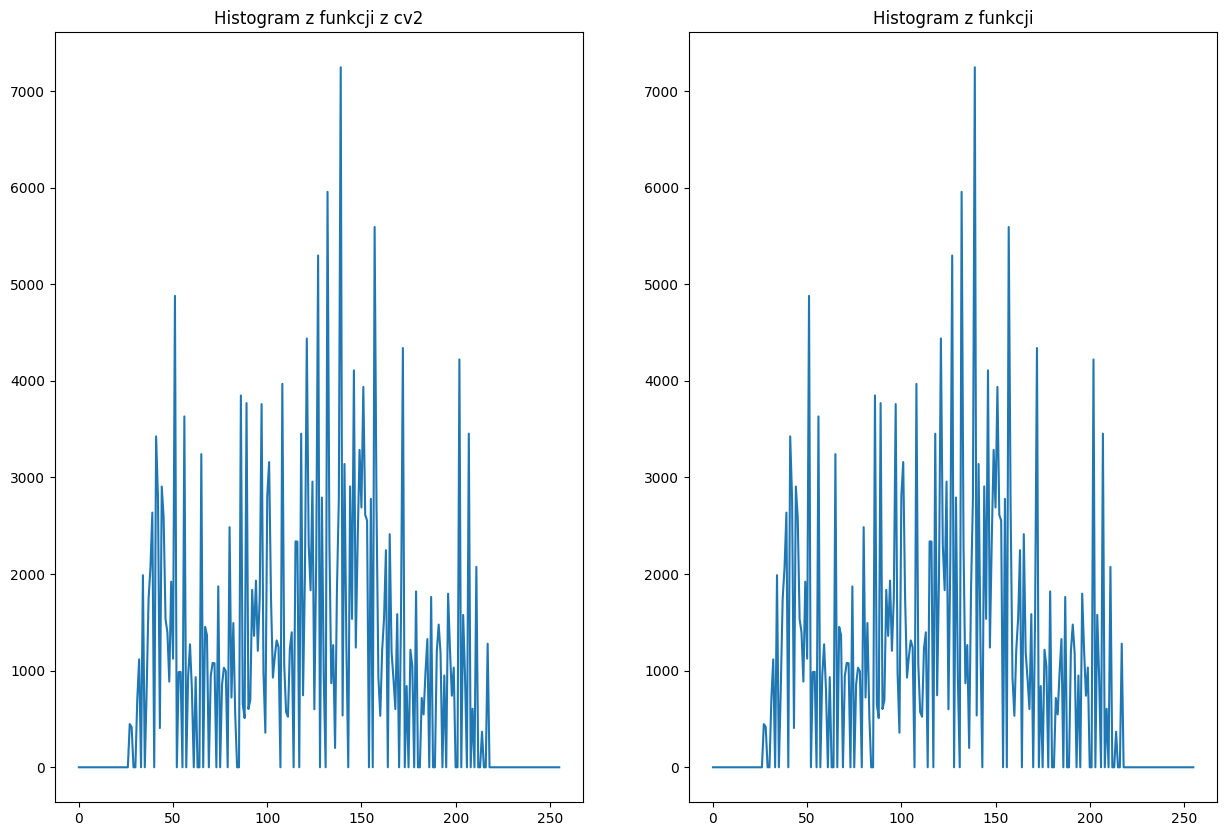

In [51]:
lena_hist_cv2 = cv2.calcHist([lena], [0], None, [256], [0,256])
lena_hist_fun = hist(lena)

fig, ax = plt.subplots(1,2, figsize=(15,10))
ax[0].plot(lena_hist_cv2)
ax[0].set_title('Histogram z funkcji z cv2')
ax[1].plot(lena_hist_fun)
ax[1].set_title('Histogram z funkcji')
plt.show()

cv2.waitKey(10)
cv2.destroyAllWindows()

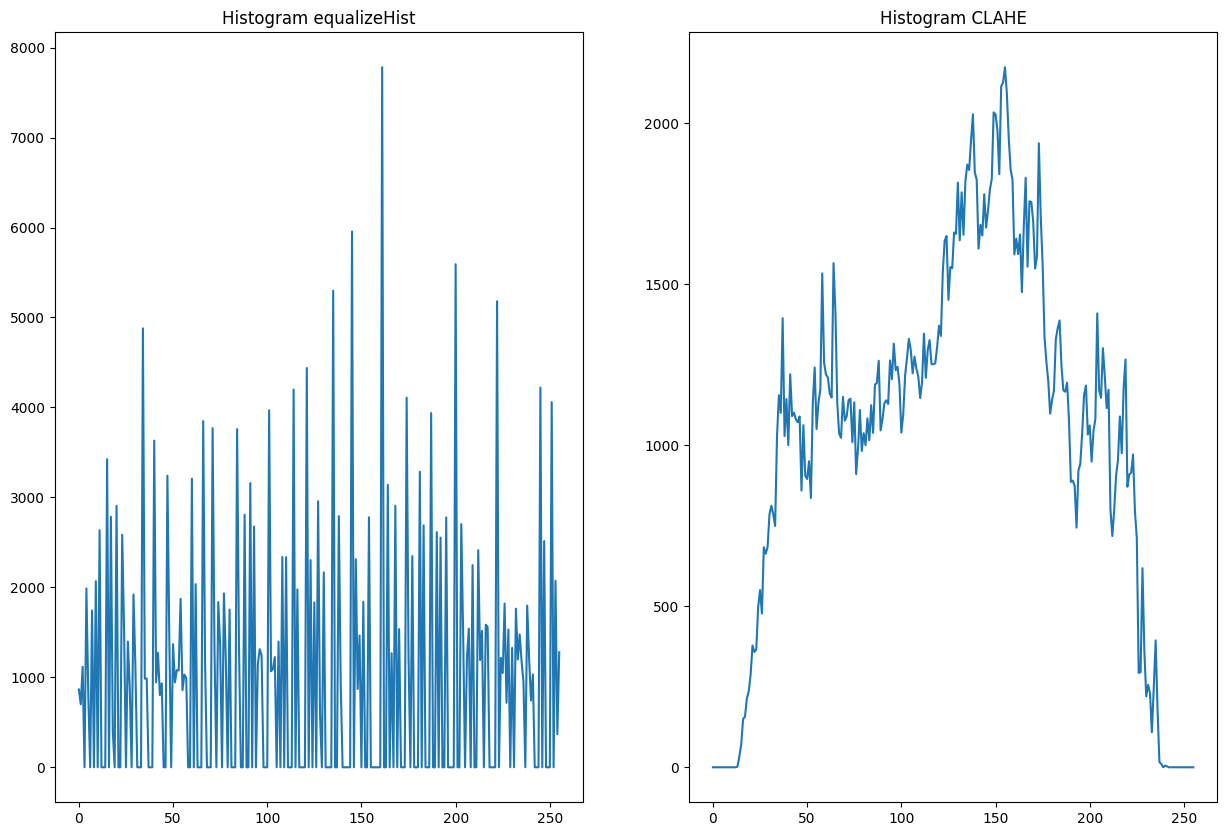

In [53]:
IGE = cv2.equalizeHist(lena)
IGE_hist = cv2.calcHist([IGE], [0], None, [256], [0,256])

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
I_CLAHE = clahe.apply(lena)
I_CLAHE_hist = cv2.calcHist([I_CLAHE], [0], None, [256], [0,256])

fig, ax = plt.subplots(1, 2, figsize=(15,10))
ax[0].plot(IGE_hist)
ax[0].set_title("Histogram equalizeHist")

ax[1].plot(I_CLAHE_hist)
ax[1].set_title("Histogram CLAHE")

plt.show()

cv2.waitKey(10)
cv2.destroyAllWindows()

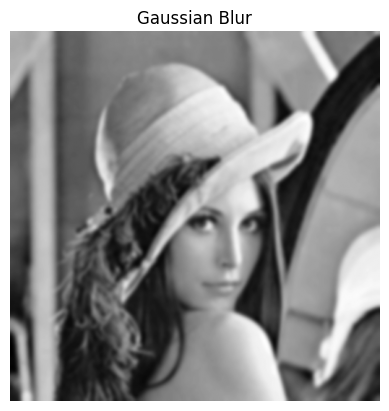

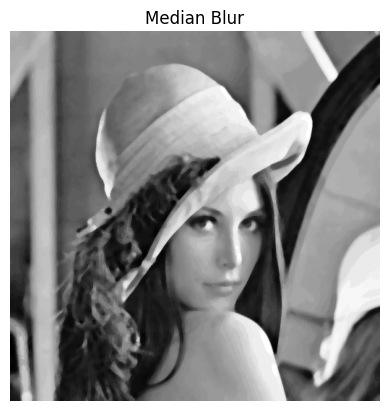

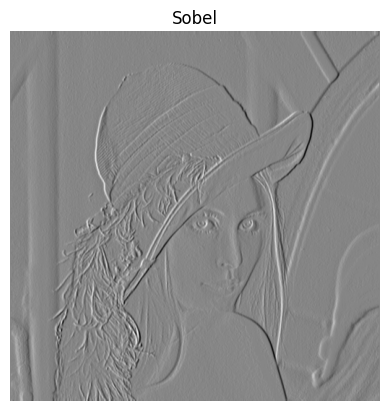

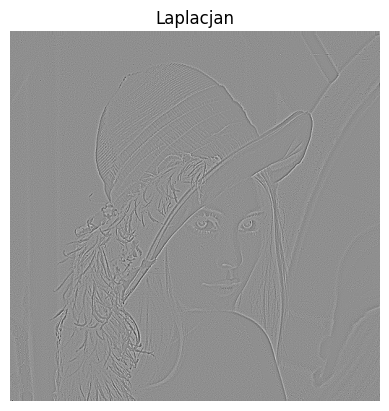

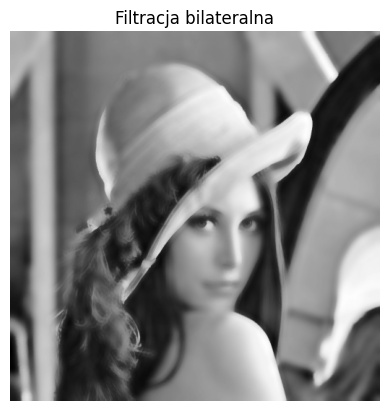

In [56]:
gaussianBlur_lena = cv2.GaussianBlur(lena, (15, 15), 0)
plt.imshow(gaussianBlur_lena, cmap='gray'); plt.title("Gaussian Blur"); plt.axis('off'); plt.show()

median_lena = cv2.medianBlur(lena, 7)
plt.imshow(median_lena, cmap='gray'); plt.title("Median Blur"); plt.axis('off'); plt.show()

sobel_lena =  cv2.Sobel(lena, cv2.CV_64F, 1, 0, ksize=3)
plt.imshow(sobel_lena, cmap='gray'); plt.title("Sobel"); plt.axis('off'); plt.show()

laplacian_lena = cv2.Laplacian(lena, cv2.CV_64F)
plt.imshow(laplacian_lena, cmap='gray'); plt.title("Laplacjan"); plt.axis('off'); plt.show()

bilateral_lena = cv2.bilateralFilter(lena, 15, 75, 75)
plt.imshow(bilateral_lena, cmap='gray'); plt.title("Filtracja bilateralna"); plt.axis('off'); plt.show()

cv2.waitKey(30)
cv2.destroyAllWindows()